In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset (replace the file path with the actual location of the dataset)
data = pd.read_csv('/content/hour.csv')

# Preview the dataset
print(data.head())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


In [ ]:
# Extract hour and month from the dataset
data['hr'] = data['hr']
data['month'] = data['mnth']

# Create the 'count' column by summing 'casual' and 'registered'
data['count'] = data['casual'] + data['registered']

# You can choose specific features based on domain knowledge or experiment
features = ['hr', 'season', 'holiday', 'weekday', 'workingday', 'temp', 'hum', 'windspeed', 'month']
X = data[features]

# Target variable: count of bike rentals (casual + registered)
y = data['count']

In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]}")
print(f"Testing data size: {X_test.shape[0]}")

Training data size: 13903
Testing data size: 3476


In [ ]:
# Initialize the DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

# Calculate R-squared (R²) score
r2 = r2_score(y_test, y_pred)
print(f'R-squared (R²): {r2}')

Mean Absolute Error (MAE): 56.541426927502876
R-squared (R²): 0.7270422122321681


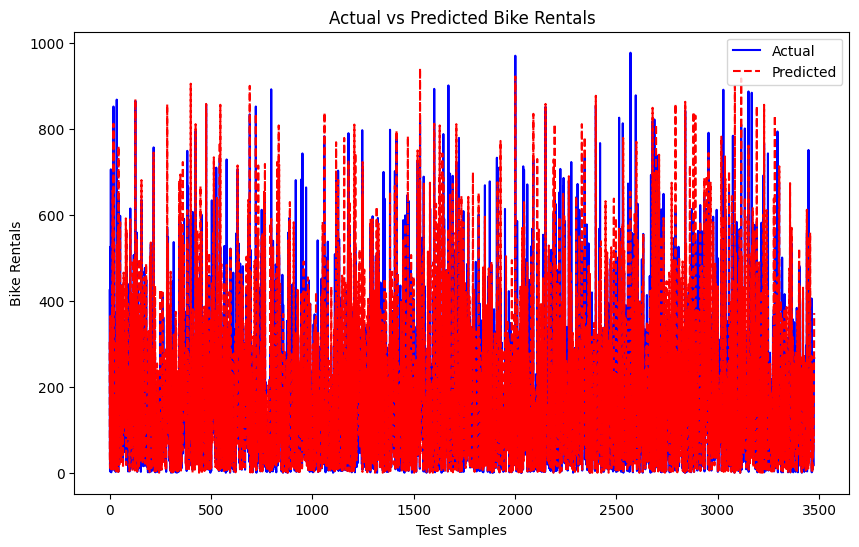

In [ ]:
# Plot Actual vs Predicted Bike Rentals
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Bike Rentals')
plt.xlabel('Test Samples')
plt.ylabel('Bike Rentals')
plt.legend()
plt.show()

In [ ]:
# Example: Predicting for 3 PM, summer, non-holiday, 25°C temperature, and 0.5 m/s windspeed
new_data = pd.DataFrame({
    'hr': [15],             # 3 PM
    'season': [2],          # Summer
    'holiday': [0],         # Not a holiday
    'weekday': [2],         # Assume it's Tuesday
    'workingday': [1],      # Working day
    'temp': [0.5],          # 25°C
    'hum': [0.6],           # 60% humidity
    'windspeed': [0.5],     # 0.5 m/s windspeed
    'month': [6]            # June
})

# Make the prediction
predicted_bike_rentals = model.predict(new_data)
print(f'Predicted number of bike rentals: {predicted_bike_rentals[0]}')

Predicted number of bike rentals: 210.0


In [ ]:
# Hyperparameter tuning (optional)
model_tuned = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=5, min_samples_leaf=3)
model_tuned.fit(X_train, y_train)

# Evaluate the tuned model
y_pred_tuned = model_tuned.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)
print(f'R-squared (R²) for tuned model: {r2_tuned}')

R-squared (R²) for tuned model: 0.805756196312944
